# CNN - VNINDEX

## Descriptions
1. Features: ["sma_"]
1. Target: "return_5"
1. Timeshift: 30
1. Forecast horizon: 5
1. Remove dayoffs

## Deploy TensorBoard

In [1]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [2]:
import os
import sys
from datetime import datetime, timedelta
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, EfficientFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname
from sklearn.inspection import permutation_importance
import xgboost as xgb
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)
from ta.ta_functions import *

## Helper functions

In [3]:
def get_weekends(from_date: str, to_date: str):
    start = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    weekends = []
    current = start

    while current <= end:
        if current.weekday() in (5, 6):  # 5 = Saturday, 6 = Sunday
            weekends.append(current.strftime("%Y-%m-%d"))
        current += timedelta(days=1)

    return weekends

## Parameters

In [4]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 5
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 5
COLUMN_ID = "stock"
TARGET_COLUMN = "return_5"
DATE_COLUMN = "date"
FEATURE_COLUMNS = []  # all TA indicators

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

In [5]:
WEEKENDS = get_weekends(TRAIN_RANGE[0], TEST_RANGE[1])
HOLIDAYS = []

DAYOFFS = []
DAYOFFS.extend(WEEKENDS)
DAYOFFS.extend(HOLIDAYS)

DAYOFFS[:10], DAYOFFS[-10:]

(['2000-01-01',
  '2000-01-02',
  '2000-01-08',
  '2000-01-09',
  '2000-01-15',
  '2000-01-16',
  '2000-01-22',
  '2000-01-23',
  '2000-01-29',
  '2000-01-30'],
 ['2026-01-24',
  '2026-01-25',
  '2026-01-31',
  '2026-02-01',
  '2026-02-07',
  '2026-02-08',
  '2026-02-14',
  '2026-02-15',
  '2026-02-21',
  '2026-02-22'])

## Hyper Parameters

In [6]:
MAX_EPOCHS = 3000
LEARNING_RATE = 1.0e-05
PATIENCE = 100
BATCH_SIZE = 128

In [7]:
MODEL_PARAMS = {"remove_dayoffs": True}
MODEL_PARAMS

{'remove_dayoffs': True}

## Start

### Get data

In [8]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [9]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [10]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [11]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [12]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "adjust": float,
    "change": float,
    "percent_change": float,
    "matching_volume": float,
    "matching_value": float,
    "negotiate_volume": float,
    "negotiate_value": float,
    "number_of_buy_orders": float,
    "buy_volume": float,
    "average_volume_per_buy_order": float,
    "number_of_sell_orders": float,
    "sell_volume": float,
    "average_volume_per_sell_order": float,
    "net_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [13]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970000,4.740000,8.169220e+06,515.250,350040.0,29.100000,26816.0,5.268141e+07,1965.000000,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.190,25.363333,4.106667,1.314382e+07,829.830,769057.0,45.943333,27442.0,5.068024e+07,1852.333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.240,21.756667,3.473333,1.811842e+07,1144.410,1188073.0,62.786667,28068.0,4.867907e+07,1739.666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150000,2.840000,2.309302e+07,1458.990,1607090.0,79.630000,28694.0,4.667790e+07,1627.000000,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580000,-2.970000,1.384280e+07,837.470,226000.0,12.100000,14464.0,1.933131e+07,1337.000000,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.445000,1.837000,7.720191e+08,22429.501,26815618.0,888.449000,476711.0,1.233848e+09,2591.300000,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.140,36.050000,1.980000,7.884829e+08,22796.440,25647000.0,849.900000,486603.0,1.253004e+09,2575.000000,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.620,7.480000,0.400000,1.049005e+09,31422.570,38029568.0,1353.200000,598087.0,1.575227e+09,2634.000000,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.910,-6.710000,-0.360000,1.191506e+09,35927.380,71924150.0,2418.240000,694266.0,1.862364e+09,2682.000000,597096.0,1.892734e+09,3170.0,-3.036983e+07


### Data transformation

#### Remove DAYOFFS

In [14]:
vn_index_df_t1 = vn_index_df[~vn_index_df["date"].isin(DAYOFFS)]
vn_index_df_t1.shape

(4690, 19)

#### Calculate log return

In [15]:
vn_index_df_t2 = vn_index_df_t1.copy()
vn_index_df_t2[f"return_{FORECAST_HORIZON}"] = (
    vn_index_df_t2["close"].shift(-FORECAST_HORIZON) - vn_index_df_t1["close"]
)
# vn_index_df_t2[f"log_return_{FORECAST_HORIZON}"] = np.log(
#     vn_index_df_t2["close"].shift(-FORECAST_HORIZON) / vn_index_df_t2["close"]
# )
vn_index_df_t2 = vn_index_df_t2.dropna(how="any").reset_index(drop=True)
vn_index_df_t2

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume,return_5
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970,4.740,8169220.0,515.250,350040.0,29.100,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,43624370.0,3.660
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,23093020.0,1458.990,1607090.0,79.630,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,13407520.0,-42.580
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,13842800.0,837.470,226000.0,12.100,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8782960.0,-50.450
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,12166910.0,765.970,290070.0,20.370,16836.0,2.378011e+07,1412.0,12032.0,2.034621e+07,1691.0,3433900.0,-70.450
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8930090.0,584.450,289160.0,17.030,13298.0,1.703506e+07,1281.0,12256.0,1.900562e+07,1551.0,-1970560.0,-82.780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,623845100.0,19127.050,37333182.0,1235.390,387678.0,1.061450e+09,2738.0,325388.0,1.058963e+09,3254.0,2486986.0,25.235
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,673236440.0,20227.867,33827327.0,1119.743,417356.0,1.118916e+09,2689.1,348156.0,1.105457e+09,3185.3,13458978.0,25.235
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,689700220.0,20594.806,32658709.0,1081.194,427248.0,1.138071e+09,2672.8,355745.0,1.120955e+09,3162.4,17116309.0,29.110
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,706164000.0,20961.745,31490091.0,1042.645,437141.0,1.157227e+09,2656.5,363335.0,1.136453e+09,3139.5,20773640.0,18.795


#### Create features

In [16]:
vn_index_df_t3 = add_one_for_all_ta(vn_index_df_t2)
# vn_index_df_t3 = vn_index_df_t2

In [17]:
FEATURE_COLUMNS = list(
    vn_index_df_t3.columns.drop(
        [
            DATE_COLUMN,
            TARGET_COLUMN,
            # "open",
            # "high",
            # "low",
            # "adjust",
            # "change",
            # "percent_change",
            # "matching_volume",
            # "matching_value",
            # "negotiate_volume",
            # "negotiate_value",
            # "close",
            # "number_of_buy_orders",
            # "buy_volume",
        ]
    )
)
FEATURE_COLUMNS

['open',
 'high',
 'low',
 'close',
 'adjust',
 'change',
 'percent_change',
 'matching_volume',
 'matching_value',
 'negotiate_volume',
 'negotiate_value',
 'number_of_buy_orders',
 'buy_volume',
 'average_volume_per_buy_order',
 'number_of_sell_orders',
 'sell_volume',
 'average_volume_per_sell_order',
 'net_volume',
 'close_bb_5_upper',
 'close_bb_5_middle',
 'close_bb_5_lower',
 'close_bb_5_dist_upper',
 'close_bb_5_dist_middle',
 'close_bb_5_dist_lower',
 'close_bb_5_slope_upper',
 'close_bb_5_slope_middle',
 'close_bb_5_slope_lower',
 'close_bb_10_upper',
 'close_bb_10_middle',
 'close_bb_10_lower',
 'close_bb_10_dist_upper',
 'close_bb_10_dist_middle',
 'close_bb_10_dist_lower',
 'close_bb_10_slope_upper',
 'close_bb_10_slope_middle',
 'close_bb_10_slope_lower',
 'close_bb_15_upper',
 'close_bb_15_middle',
 'close_bb_15_lower',
 'close_bb_15_dist_upper',
 'close_bb_15_dist_middle',
 'close_bb_15_dist_lower',
 'close_bb_15_slope_upper',
 'close_bb_15_slope_middle',
 'close_bb_15_

In [18]:
vn_index_df_final = vn_index_df_t3[[DATE_COLUMN] + FEATURE_COLUMNS + [TARGET_COLUMN]]
vn_index_df_final

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_wma_15_slope,close_wma_20,close_wma_20_slope,close_wma_5_10_dist,close_wma_5_15_dist,close_wma_5_20_dist,close_wma_10_15_dist,close_wma_10_20_dist,close_wma_15_20_dist,return_5
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970,4.740,8169220.0,515.250,...,NaN,640.140000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.660
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,23093020.0,1458.990,...,1.210000,641.047500,0.907500,1.815000,2.420000,2.722500,0.605000,0.907500,0.302500,-42.580
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,13842800.0,837.470,...,-0.176000,640.930625,-0.116875,1.127500,1.584000,1.827375,0.456500,0.699875,0.243375,-50.450
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,12166910.0,765.970,...,0.181733,641.079094,0.148469,1.128950,1.630667,1.907306,0.501717,0.778356,0.276640,-70.450
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8930090.0,584.450,...,0.416284,641.405139,0.326045,1.477415,2.137102,2.503981,0.659687,1.026566,0.366879,-82.780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,623845100.0,19127.050,...,1.275829,1799.204536,1.309761,-8.285735,-7.220737,-0.196885,1.064998,8.088851,7.023852,25.235
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,673236440.0,20227.867,...,1.911774,1800.989559,1.785023,-3.867427,-1.953041,5.197562,1.914386,9.064989,7.150603,25.235
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,689700220.0,20594.806,...,2.024656,1802.865581,1.876022,-0.248396,2.486879,9.786116,2.735275,10.034512,7.299237,29.110
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,706164000.0,20961.745,...,2.130012,1804.828052,1.962471,2.722774,6.249527,13.716305,3.526753,10.993532,7.466778,18.795


In [19]:
vn_index_df_final.loc[:, "stock"] = "vn_index"
vn_index_df_final

C:\Users\Trung.MSI\AppData\Local\Temp\ipykernel_28964\1961083148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_final.loc[:, "stock"] = "vn_index"


,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_wma_20,close_wma_20_slope,close_wma_5_10_dist,close_wma_5_15_dist,close_wma_5_20_dist,close_wma_10_15_dist,close_wma_10_20_dist,close_wma_15_20_dist,return_5,stock
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970,4.740,8169220.0,515.250,...,640.140000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.660,vn_index
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,23093020.0,1458.990,...,641.047500,0.907500,1.815000,2.420000,2.722500,0.605000,0.907500,0.302500,-42.580,vn_index
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,13842800.0,837.470,...,640.930625,-0.116875,1.127500,1.584000,1.827375,0.456500,0.699875,0.243375,-50.450,vn_index
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,12166910.0,765.970,...,641.079094,0.148469,1.128950,1.630667,1.907306,0.501717,0.778356,0.276640,-70.450,vn_index
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8930090.0,584.450,...,641.405139,0.326045,1.477415,2.137102,2.503981,0.659687,1.026566,0.366879,-82.780,vn_index
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,623845100.0,19127.050,...,1799.204536,1.309761,-8.285735,-7.220737,-0.196885,1.064998,8.088851,7.023852,25.235,vn_index
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,673236440.0,20227.867,...,1800.989559,1.785023,-3.867427,-1.953041,5.197562,1.914386,9.064989,7.150603,25.235,vn_index
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,689700220.0,20594.806,...,1802.865581,1.876022,-0.248396,2.486879,9.786116,2.735275,10.034512,7.299237,29.110,vn_index
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,706164000.0,20961.745,...,1804.828052,1.962471,2.722774,6.249527,13.716305,3.526753,10.993532,7.466778,18.795,vn_index


In [20]:
vn_index_df_final = vn_index_df_final.dropna(how="any")
vn_index_df_final.shape

(4570, 228)

In [21]:
input_df = vn_index_df_final
input_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_wma_20,close_wma_20_slope,close_wma_5_10_dist,close_wma_5_15_dist,close_wma_5_20_dist,close_wma_10_15_dist,close_wma_10_20_dist,close_wma_15_20_dist,return_5,stock
115,2008-08-15,488.810,489.180,488.690,488.940,488.940,12.440,2.610,8824290.0,319.300,...,447.015724,2.206541,8.453143,13.367846,15.557754,4.914703,7.104610,2.189908,38.040,vn_index
116,2008-08-18,504.140,508.480,503.650,508.050,508.050,19.110,3.910,16903560.0,743.990,...,450.067437,3.051714,12.155481,18.540193,21.601344,6.384711,9.445863,3.061152,40.200,vn_index
117,2008-08-19,520.510,520.510,506.760,511.530,511.530,3.480,0.680,32034240.0,1296.540,...,453.140566,3.073128,14.926055,22.619009,26.500460,7.692954,11.574405,3.881451,50.140,vn_index
118,2008-08-20,497.750,514.950,497.750,508.470,508.470,-3.060,-0.600,30560540.0,1171.060,...,455.907037,2.766472,16.316347,24.954938,29.499783,8.638591,13.183436,4.544845,53.380,vn_index
119,2008-08-21,512.540,525.980,510.690,525.980,525.980,17.510,3.440,23831770.0,977.290,...,459.410685,3.503648,18.742030,28.701033,34.110771,9.959003,15.368741,5.409738,21.710,vn_index
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,623845100.0,19127.050,...,1799.204536,1.309761,-8.285735,-7.220737,-0.196885,1.064998,8.088851,7.023852,25.235,vn_index
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,673236440.0,20227.867,...,1800.989559,1.785023,-3.867427,-1.953041,5.197562,1.914386,9.064989,7.150603,25.235,vn_index
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,689700220.0,20594.806,...,1802.865581,1.876022,-0.248396,2.486879,9.786116,2.735275,10.034512,7.299237,29.110,vn_index
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,706164000.0,20961.745,...,1804.828052,1.962471,2.722774,6.249527,13.716305,3.526753,10.993532,7.466778,18.795,vn_index


### Feature Importance

In [22]:
TOP_N = 50

In [23]:
FEATURE_COLUMNS

['open',
 'high',
 'low',
 'close',
 'adjust',
 'change',
 'percent_change',
 'matching_volume',
 'matching_value',
 'negotiate_volume',
 'negotiate_value',
 'number_of_buy_orders',
 'buy_volume',
 'average_volume_per_buy_order',
 'number_of_sell_orders',
 'sell_volume',
 'average_volume_per_sell_order',
 'net_volume',
 'close_bb_5_upper',
 'close_bb_5_middle',
 'close_bb_5_lower',
 'close_bb_5_dist_upper',
 'close_bb_5_dist_middle',
 'close_bb_5_dist_lower',
 'close_bb_5_slope_upper',
 'close_bb_5_slope_middle',
 'close_bb_5_slope_lower',
 'close_bb_10_upper',
 'close_bb_10_middle',
 'close_bb_10_lower',
 'close_bb_10_dist_upper',
 'close_bb_10_dist_middle',
 'close_bb_10_dist_lower',
 'close_bb_10_slope_upper',
 'close_bb_10_slope_middle',
 'close_bb_10_slope_lower',
 'close_bb_15_upper',
 'close_bb_15_middle',
 'close_bb_15_lower',
 'close_bb_15_dist_upper',
 'close_bb_15_dist_middle',
 'close_bb_15_dist_lower',
 'close_bb_15_slope_upper',
 'close_bb_15_slope_middle',
 'close_bb_15_

In [24]:
TARGET_COLUMN

'return_5'

In [25]:
# Convert date
input_df[DATE_COLUMN] = pd.to_datetime(input_df[DATE_COLUMN])

# -----------------------------
# TRAIN DATA
# -----------------------------
X = input_df[FEATURE_COLUMNS]
y = input_df[TARGET_COLUMN]

# -----------------------------
# GPU XGBOOST MODEL
# -----------------------------
model = xgb.XGBRegressor(
    n_estimators=4000,
    max_depth=16,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=RANDOM_SEED,
)

model.fit(X, y)

# -----------------------------
# PERMUTATION IMPORTANCE
# -----------------------------
result = permutation_importance(
    model,
    X,
    y,
    n_repeats=40,
    random_state=RANDOM_SEED,
    n_jobs=16,
    scoring="neg_mean_squared_error",
)

# -----------------------------
# CREATE IMPORTANCE DF
# -----------------------------
importance_df = pd.DataFrame(
    {"feature": FEATURE_COLUMNS, "importance": result.importances_mean}
).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum() * 100
)

print("\nFeature Importance:")
print(importance_df)

C:\Users\Trung.MSI\AppData\Local\Temp\ipykernel_28964\1376275300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df[DATE_COLUMN] = pd.to_datetime(input_df[DATE_COLUMN])



Feature Importance:
                          feature  importance  importance_pct
13   average_volume_per_buy_order   47.329760       11.344788
95          close_kama_15_20_dist   22.273329        5.338844
91           close_kama_5_15_dist   21.722982        5.206927
92           close_kama_5_20_dist   18.864381        4.521730
201           close_trima_15_dist   12.850017        3.080107
..                            ...         ...             ...
136      close_to_sar_004_02_sign    0.001138        0.000273
145                  close_sma_10    0.001025        0.000246
211                   close_wma_5    0.000090        0.000021
147                  close_sma_15    0.000037        0.000009
132      close_to_sar_002_02_sign    0.000000        0.000000

[225 rows x 3 columns]


In [26]:
importance_df

,feature,importance,importance_pct
13,average_volume_per_buy_order,47.329760,11.344788
95,close_kama_15_20_dist,22.273329,5.338844
91,close_kama_5_15_dist,21.722982,5.206927
92,close_kama_5_20_dist,18.864381,4.521730
201,close_trima_15_dist,12.850017,3.080107
...,...,...,...
136,close_to_sar_004_02_sign,0.001138,0.000273
145,close_sma_10,0.001025,0.000246
211,close_wma_5,0.000090,0.000021
147,close_sma_15,0.000037,0.000009


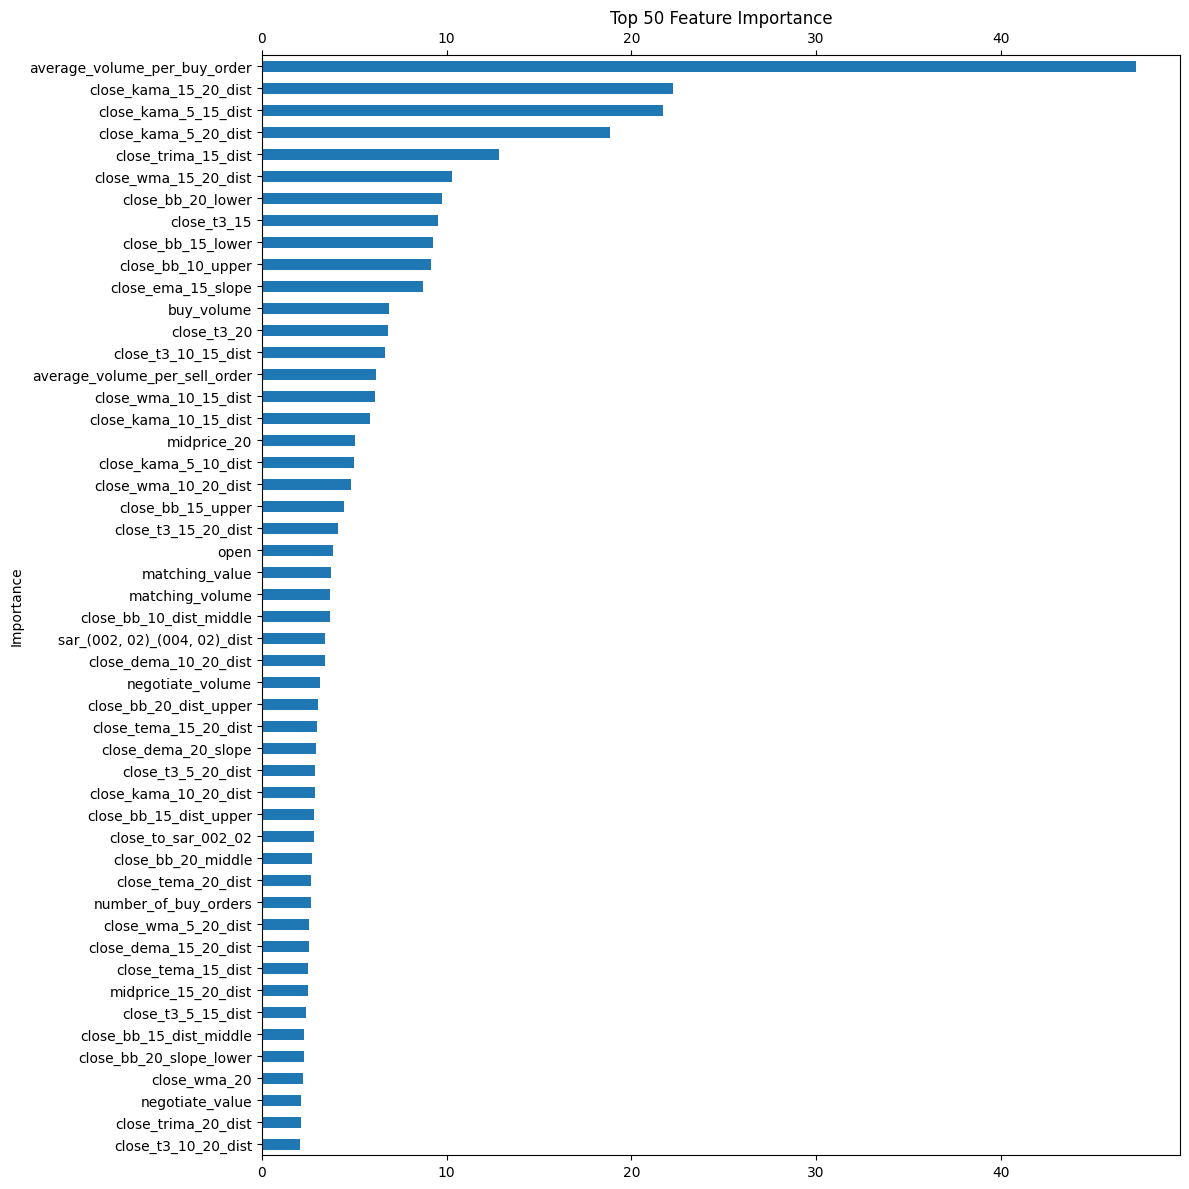

In [27]:
top_features = (
    importance_df.sort_values("importance", ascending=False)
    .head(TOP_N)
    .set_index("feature")["importance"]
).sort_values(ascending=True)

# Plot
ax = top_features.plot(kind="barh", figsize=(12, 12))

plt.title(f"Top {TOP_N} Feature Importance")
plt.ylabel("Importance")

# Show x ticks on both top and bottom
ax.xaxis.set_ticks_position("both")
ax.tick_params(axis="x", which="both", top=True, bottom=True, labeltop=True)

plt.tight_layout()
plt.show()

In [28]:
TOP_N_FEATURES = list(top_features.index)
TOP_N_FEATURES

['close_t3_10_20_dist',
 'close_trima_20_dist',
 'negotiate_value',
 'close_wma_20',
 'close_bb_20_slope_lower',
 'close_bb_15_dist_middle',
 'close_t3_5_15_dist',
 'midprice_15_20_dist',
 'close_tema_15_dist',
 'close_dema_15_20_dist',
 'close_wma_5_20_dist',
 'number_of_buy_orders',
 'close_tema_20_dist',
 'close_bb_20_middle',
 'close_to_sar_002_02',
 'close_bb_15_dist_upper',
 'close_kama_10_20_dist',
 'close_t3_5_20_dist',
 'close_dema_20_slope',
 'close_tema_15_20_dist',
 'close_bb_20_dist_upper',
 'negotiate_volume',
 'close_dema_10_20_dist',
 'sar_(002, 02)_(004, 02)_dist',
 'close_bb_10_dist_middle',
 'matching_volume',
 'matching_value',
 'open',
 'close_t3_15_20_dist',
 'close_bb_15_upper',
 'close_wma_10_20_dist',
 'close_kama_5_10_dist',
 'midprice_20',
 'close_kama_10_15_dist',
 'close_wma_10_15_dist',
 'average_volume_per_sell_order',
 'close_t3_10_15_dist',
 'close_t3_20',
 'buy_volume',
 'close_ema_15_slope',
 'close_bb_10_upper',
 'close_bb_15_lower',
 'close_t3_15',


### Feature Selection

In [29]:
CORR_THRESHOLD = 0.95

# Correlation matrix (absolute values)
corr_matrix = input_df[FEATURE_COLUMNS].corr().abs()

# Features sorted by importance
sorted_features = importance_df.sort_values("importance", ascending=False)[
    "feature"
].tolist()

selected_features = []
removed_features = set()

for feature in sorted_features:

    if feature in removed_features:
        continue

    selected_features.append(feature)

    # Find correlated features
    correlated = corr_matrix.index[corr_matrix[feature] > CORR_THRESHOLD].tolist()

    for corr_feature in correlated:
        if corr_feature != feature:
            removed_features.add(corr_feature)

print("Selected features:", len(selected_features))
print("Removed features:", len(removed_features))

print("\nTop kept features:")
print(selected_features[:TOP_N])

print("\nRemoved features:")
print(list(removed_features))

Selected features: 109
Removed features: 116

Top kept features:
['average_volume_per_buy_order', 'close_kama_15_20_dist', 'close_kama_5_15_dist', 'close_kama_5_20_dist', 'close_trima_15_dist', 'close_wma_15_20_dist', 'close_bb_20_lower', 'buy_volume', 'close_t3_10_15_dist', 'average_volume_per_sell_order', 'close_kama_10_15_dist', 'close_kama_5_10_dist', 'close_t3_15_20_dist', 'matching_value', 'close_bb_10_dist_middle', 'sar_(002, 02)_(004, 02)_dist', 'close_dema_10_20_dist', 'negotiate_volume', 'close_bb_20_dist_upper', 'close_tema_15_20_dist', 'close_t3_5_20_dist', 'close_kama_10_20_dist', 'close_to_sar_002_02', 'close_tema_20_dist', 'number_of_buy_orders', 'close_wma_5_20_dist', 'close_tema_15_dist', 'midprice_15_20_dist', 'close_bb_15_dist_middle', 'close_bb_20_slope_lower', 'negotiate_value', 'close_dema_5_10_dist', 'close_to_sar_002_02_pct', 'midprice_5_slope', 'close_midpoint_15_20_dist', 'close_t3_20_slope', 'close_kama_15_slope', 'midprice_10_20_dist', 'net_volume', 'close_t

### Feature Correlation

Correlation Matrix:


,average_volume_per_buy_order,close_kama_15_20_dist,close_kama_5_15_dist,close_kama_5_20_dist,close_trima_15_dist,close_wma_15_20_dist,close_bb_20_lower,buy_volume,close_t3_10_15_dist,average_volume_per_sell_order,...,close_bb_20_slope_upper,close_midpoint_5_20_dist,midprice_5_10_dist,close_bb_20_slope_middle,close_tema_10_15_dist,close_tema_15_slope,close_kama_10_slope,close_sma_15_20_dist,close_kama_20_slope,sar_002_02_slope
average_volume_per_buy_order,1.000000,0.100217,0.126705,0.141912,0.151422,0.084958,-0.117631,0.170955,0.097246,0.852424,...,0.122979,0.103344,0.066140,0.138563,0.048578,0.156187,0.135255,0.093739,0.149278,-0.004020
close_kama_15_20_dist,0.100217,1.000000,0.309900,0.680424,0.346761,0.269715,0.127543,0.188861,0.611067,0.106066,...,0.354766,0.546226,0.300993,0.551840,-0.096728,0.182849,0.315780,0.625652,0.492882,0.237561
close_kama_5_15_dist,0.126705,0.309900,1.000000,0.907605,0.703625,0.313712,0.014892,0.113744,0.492752,0.056910,...,0.333289,0.666946,0.631896,0.575114,0.350580,0.508209,0.648842,0.408977,0.530654,0.346055
close_kama_5_20_dist,0.141912,0.680424,0.907605,1.000000,0.695446,0.360894,0.067796,0.171064,0.649620,0.090699,...,0.413539,0.755251,0.619950,0.686950,0.227503,0.472448,0.639541,0.591490,0.626648,0.371625
close_trima_15_dist,0.151422,0.346761,0.703625,0.695446,1.000000,0.304766,0.047953,0.159180,0.470406,-0.015501,...,0.313440,0.699758,0.731820,0.685714,0.647459,0.904993,0.870898,0.385649,0.790666,0.243215
close_wma_15_20_dist,0.084958,0.269715,0.313712,0.360894,0.304766,1.000000,0.275710,0.276356,0.378133,0.148532,...,0.463100,0.536161,0.282583,0.643657,-0.236126,0.112545,0.272520,0.616955,0.433025,0.159922
close_bb_20_lower,-0.117631,0.127543,0.014892,0.067796,0.047953,0.275710,1.000000,0.724553,0.033468,0.087493,...,0.082369,0.135861,0.091327,0.114310,-0.040630,0.017359,0.042516,0.104823,0.073632,0.018502
buy_volume,0.170955,0.188861,0.113744,0.171064,0.159180,0.276356,0.724553,1.000000,0.153412,0.255541,...,0.187364,0.236944,0.161415,0.216699,-0.007225,0.102960,0.147980,0.189244,0.184268,0.056521
close_t3_10_15_dist,0.097246,0.611067,0.492752,0.649620,0.470406,0.378133,0.033468,0.153412,1.000000,0.091314,...,0.524551,0.848599,0.485134,0.851987,-0.276464,0.178614,0.401265,0.898771,0.604912,0.364621
average_volume_per_sell_order,0.852424,0.106066,0.056910,0.090699,-0.015501,0.148532,0.087493,0.255541,0.091314,1.000000,...,0.120343,0.088115,0.031519,0.081508,-0.101983,-0.075658,-0.021502,0.110041,0.026059,0.053635


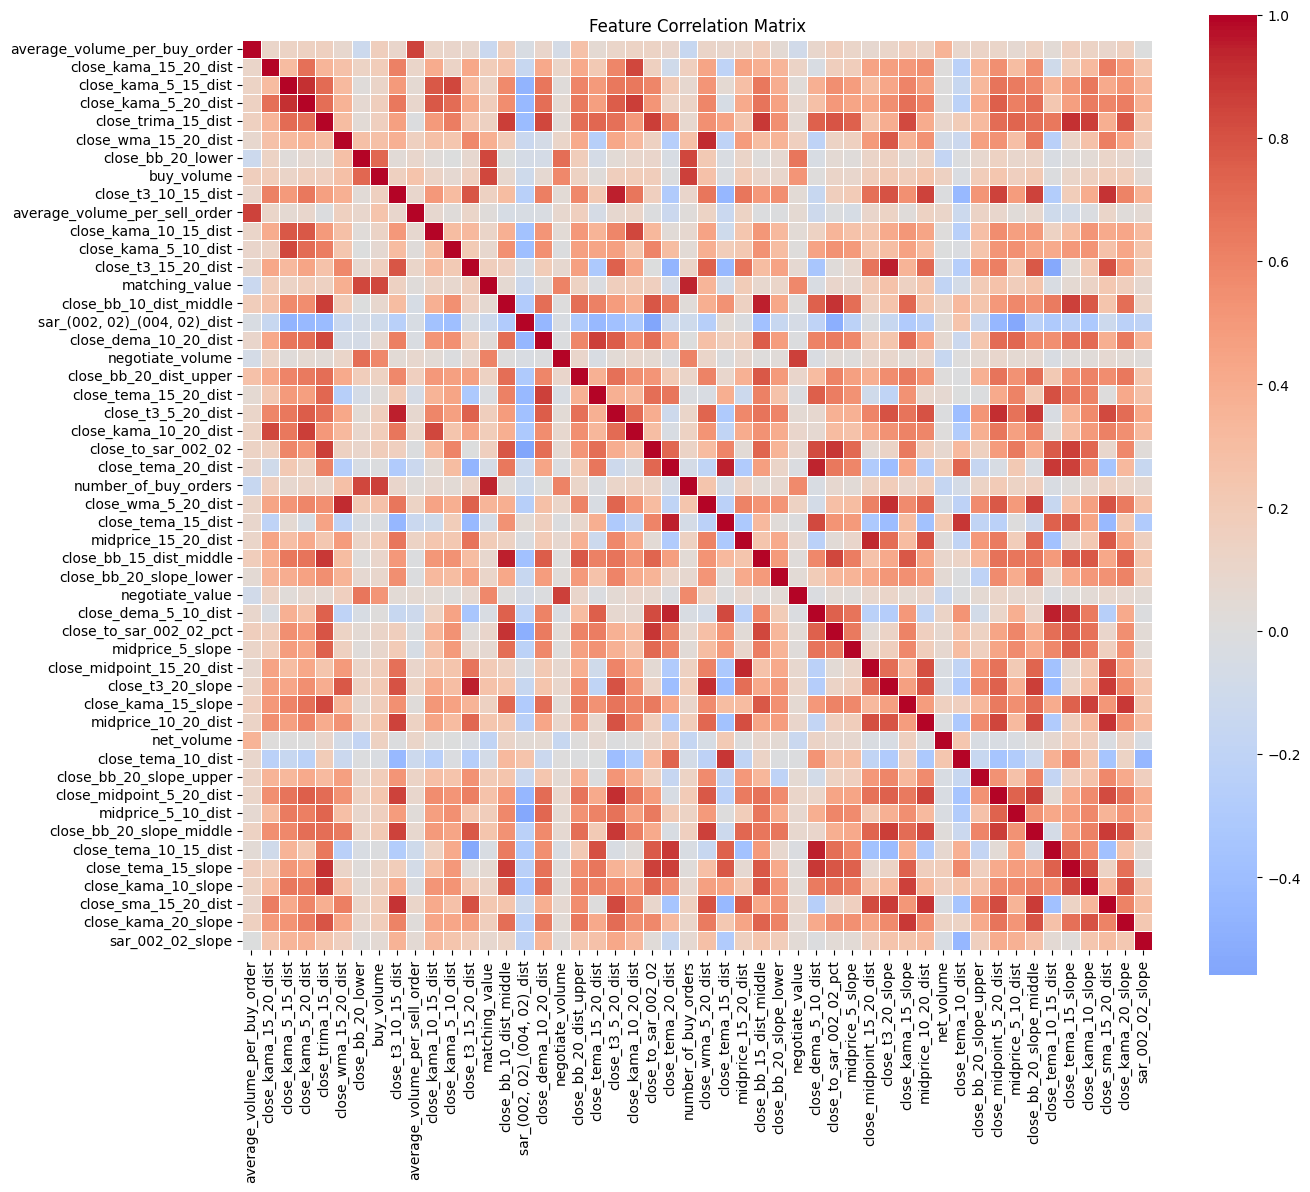

In [30]:
corr_matrix = input_df[selected_features[:TOP_N]].corr()

print("Correlation Matrix:")
display(corr_matrix)

# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
plt.figure(figsize=(14, 12))

sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [31]:
FINAL_FEATURE_COLUMNS = selected_features[:TOP_N]

print("Original feature count:", len(FEATURE_COLUMNS))
print("Final feature count:", len(FINAL_FEATURE_COLUMNS))

X_filtered = input_df[FINAL_FEATURE_COLUMNS]
X_filtered

Original feature count: 225
Final feature count: 50


,average_volume_per_buy_order,close_kama_15_20_dist,close_kama_5_15_dist,close_kama_5_20_dist,close_trima_15_dist,close_wma_15_20_dist,close_bb_20_lower,buy_volume,close_t3_10_15_dist,average_volume_per_sell_order,...,close_bb_20_slope_upper,close_midpoint_5_20_dist,midprice_5_10_dist,close_bb_20_slope_middle,close_tema_10_15_dist,close_tema_15_slope,close_kama_10_slope,close_sma_15_20_dist,close_kama_20_slope,sar_002_02_slope
115,2926.0,5.281814,9.576213,14.858026,42.969063,2.189908,419.091713,6.579682e+07,-6.624424,2631.0,...,1.705485,12.6700,12.705,0.29450,8.691818,10.325596,4.888514,0.692167,0.215120,3.702873
116,2687.0,11.693407,15.551185,27.244592,58.916563,3.061152,412.756355,5.689263e+07,-3.483179,2317.0,...,10.058359,15.2150,13.820,1.86150,10.831729,14.053390,13.142221,3.724667,1.935896,5.520304
117,2766.0,14.951320,18.090155,33.041476,58.163594,3.881451,407.577767,6.128006e+07,0.232799,2104.0,...,10.543587,17.2750,12.940,2.68250,10.958828,11.653792,15.742436,5.517500,3.706706,8.277928
118,2519.0,14.709929,16.925578,31.635507,49.865781,4.544845,405.415538,5.726322e+07,4.133606,2053.0,...,8.450229,23.5200,15.410,3.14400,9.099528,7.565271,6.365212,6.386833,4.515796,10.182873
119,2535.0,12.281944,17.872613,30.154557,61.127813,5.409738,403.132344,6.418650e+07,8.127302,2089.0,...,11.302194,29.7400,24.935,4.50950,8.820779,11.167632,10.919806,6.852000,9.850808,8.757271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2738.0,-20.033982,-4.696485,-24.730467,29.922656,7.023852,1734.009671,1.061450e+09,-43.614071,3254.0,...,-6.186483,-36.2500,-1.860,-2.75200,16.291697,13.196845,0.216302,-21.226333,0.134372,1.494800
4681,2689.1,-20.326750,12.083807,-8.242943,44.107109,7.150603,1737.479351,1.118916e+09,-39.922614,3185.3,...,-9.638181,-29.4375,0.000,-3.08425,19.502049,14.059619,1.365320,-18.729750,0.557604,3.253008
4682,2672.8,-20.623745,23.485026,2.861282,49.251719,7.299237,1741.560768,1.138071e+09,-34.720739,3162.4,...,-9.608416,-2.0550,11.295,-2.76350,20.347052,12.193274,1.266797,-15.432250,0.579228,5.385252
4683,2656.5,-19.772861,30.215215,10.442354,51.870781,7.466778,1745.245894,1.157227e+09,-28.507469,3139.5,...,-8.017626,9.7225,25.770,-2.16625,19.670066,10.632112,4.390799,-10.652333,0.511957,7.061035


### Roll time series

In [35]:
input_df_rolled = roll_time_series(
    input_df[[DATE_COLUMN] + TOP_N_FEATURES + [COLUMN_ID]],
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

c:\Users\Trung.MSI\Downloads\GIT\master-thesis\mt_env\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:520: UserWarning: Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.
  warnings.warn(
Rolling: 100%|██████████| 30/30 [00:07<00:00,  4.12it/s]


,date,close_kama_20_slope,number_of_sell_orders,close_wma_20_slope,number_of_buy_orders,close_ema_15_slope,close_tema_15_20_dist,close_dema_10_20_dist,midprice_10_20_dist,close_ema_20_slope,...,close_wma_15_20_dist,close_trima_15_dist,close_t3_15,close_kama_15_20_dist,close_kama_5_15_dist,close_kama_5_20_dist,close_bb_lower_20,average_volume_per_buy_order,stock,id
0,2008-08-15,0.215120,3865.0,2.206541,22489.0,4.600195,2.632924,7.538402,1.345,3.727599,...,2.189908,42.969063,455.333188,5.281814,9.576213,14.858026,419.091713,2926.0,vn_index,"(vn_index, 2008-08-22 00:00:00)"
1,2008-08-18,1.935896,10431.0,3.051714,21171.0,6.413920,4.912110,12.191930,1.345,5.192590,...,3.061152,58.916563,456.291053,11.693407,15.551185,27.244592,412.756355,2687.0,vn_index,"(vn_index, 2008-08-22 00:00:00)"
2,2008-08-19,3.706706,25187.0,3.073128,22158.0,6.047180,6.176688,14.935394,2.745,5.029486,...,3.881451,58.163594,458.079425,14.951320,18.090155,33.041476,407.577767,2766.0,vn_index,"(vn_index, 2008-08-22 00:00:00)"
3,2008-08-20,4.515796,24741.0,2.766472,22736.0,4.908783,6.232706,15.319339,6.440,4.259059,...,4.544845,49.865781,460.630831,14.709929,16.925578,31.635507,405.415538,2519.0,vn_index,"(vn_index, 2008-08-22 00:00:00)"
4,2008-08-21,9.850808,14313.0,3.503648,25320.0,6.483935,6.949223,17.216016,6.440,5.521053,...,5.409738,61.127813,463.968507,12.281944,17.872613,30.154557,403.132344,2535.0,vn_index,"(vn_index, 2008-08-22 00:00:00)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26467,2026-02-13,0.134372,325388.0,1.309761,387678.0,2.761282,0.858275,-10.699040,-43.600,1.732994,...,7.023852,29.922656,1833.177746,-20.033982,-4.696485,-24.730467,1734.009671,2738.0,vn_index,"(vn_index, 2026-02-19 00:00:00)"
26468,2026-02-16,0.557604,348156.0,1.785023,417356.0,3.767996,4.915676,-3.067962,-39.619,2.597947,...,7.150603,44.107109,1827.214529,-20.326750,12.083807,-8.242943,1737.479351,2689.1,vn_index,"(vn_index, 2026-02-19 00:00:00)"
26469,2026-02-17,0.579228,355745.0,1.876022,427248.0,3.747622,7.796086,2.516233,-32.397,2.693857,...,7.299237,49.251719,1822.375627,-20.623745,23.485026,2.861282,1741.560768,2672.8,vn_index,"(vn_index, 2026-02-19 00:00:00)"
26470,2026-02-18,0.511957,363335.0,1.962471,437141.0,3.729794,9.738884,6.516773,-30.450,2.780632,...,7.466778,51.870781,1818.732121,-19.772861,30.215215,10.442354,1745.245894,2656.5,vn_index,"(vn_index, 2026-02-19 00:00:00)"


In [36]:
input_df_rolled.drop(COLUMN_ID, axis=1)

,date,close_kama_20_slope,number_of_sell_orders,close_wma_20_slope,number_of_buy_orders,close_ema_15_slope,close_tema_15_20_dist,close_dema_10_20_dist,midprice_10_20_dist,close_ema_20_slope,...,close_bb_lower_15,close_wma_15_20_dist,close_trima_15_dist,close_t3_15,close_kama_15_20_dist,close_kama_5_15_dist,close_kama_5_20_dist,close_bb_lower_20,average_volume_per_buy_order,id
0,2008-08-15,0.215120,3865.0,2.206541,22489.0,4.600195,2.632924,7.538402,1.345,3.727599,...,419.580569,2.189908,42.969063,455.333188,5.281814,9.576213,14.858026,419.091713,2926.0,"(vn_index, 2008-08-22 00:00:00)"
1,2008-08-18,1.935896,10431.0,3.051714,21171.0,6.413920,4.912110,12.191930,1.345,5.192590,...,414.578363,3.061152,58.916563,456.291053,11.693407,15.551185,27.244592,412.756355,2687.0,"(vn_index, 2008-08-22 00:00:00)"
2,2008-08-19,3.706706,25187.0,3.073128,22158.0,6.047180,6.176688,14.935394,2.745,5.029486,...,411.035477,3.881451,58.163594,458.079425,14.951320,18.090155,33.041476,407.577767,2766.0,"(vn_index, 2008-08-22 00:00:00)"
3,2008-08-20,4.515796,24741.0,2.766472,22736.0,4.908783,6.232706,15.319339,6.440,4.259059,...,409.967499,4.544845,49.865781,460.630831,14.709929,16.925578,31.635507,405.415538,2519.0,"(vn_index, 2008-08-22 00:00:00)"
4,2008-08-21,9.850808,14313.0,3.503648,25320.0,6.483935,6.949223,17.216016,6.440,5.521053,...,407.338164,5.409738,61.127813,463.968507,12.281944,17.872613,30.154557,403.132344,2535.0,"(vn_index, 2008-08-22 00:00:00)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26467,2026-02-13,0.134372,325388.0,1.309761,387678.0,2.761282,0.858275,-10.699040,-43.600,1.732994,...,1745.757198,7.023852,29.922656,1833.177746,-20.033982,-4.696485,-24.730467,1734.009671,2738.0,"(vn_index, 2026-02-19 00:00:00)"
26468,2026-02-16,0.557604,348156.0,1.785023,417356.0,3.767996,4.915676,-3.067962,-39.619,2.597947,...,1746.840424,7.150603,44.107109,1827.214529,-20.326750,12.083807,-8.242943,1737.479351,2689.1,"(vn_index, 2026-02-19 00:00:00)"
26469,2026-02-17,0.579228,355745.0,1.876022,427248.0,3.747622,7.796086,2.516233,-32.397,2.693857,...,1746.039815,7.299237,49.251719,1822.375627,-20.623745,23.485026,2.861282,1741.560768,2672.8,"(vn_index, 2026-02-19 00:00:00)"
26470,2026-02-18,0.511957,363335.0,1.962471,437141.0,3.729794,9.738884,6.516773,-30.450,2.780632,...,1744.913162,7.466778,51.870781,1818.732121,-19.772861,30.215215,10.442354,1745.245894,2656.5,"(vn_index, 2026-02-19 00:00:00)"


### Extract features

In [37]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=EfficientFCParameters(),
)

Feature Extraction:   0%|          | 0/30 [00:00<?, ?it/s]

: 

: 

In [ ]:
X

In [ ]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

### Create forecast target

In [ ]:
y = (
    input_df.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)

y = pd.DataFrame(y)
y

In [ ]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [ ]:
X

In [ ]:
y

### Create train set

In [ ]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

In [ ]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

In [ ]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

### Select features

In [ ]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

### Create validation set

In [ ]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

In [ ]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

In [ ]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

### Create test set

In [ ]:
TEST_RANGE[0], TEST_RANGE[1]

In [ ]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

In [ ]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

### Validate before scaling

In [ ]:
import numpy as np


def get_bad_columns(
    df: pd.DataFrame, variance_threshold=1e-6, range_threshold=1e6
) -> np.ndarray:
    """
    Returns indices of columns that are:
    - NaN anywhere
    - Inf anywhere
    - Near-constant (variance below threshold) → causes scaler explosion
    - Extreme range (max - min above threshold) → causes scaler explosion
    """
    col_values = df.values.astype(np.float64)

    has_nan = np.isnan(col_values).any(axis=0)
    has_inf = np.isinf(col_values).any(axis=0)

    col_range = col_values.max(axis=0) - col_values.min(axis=0)
    near_constant = col_range < variance_threshold
    extreme_range = col_range > range_threshold

    bad_mask = has_nan | has_inf | near_constant | extreme_range
    return np.where(bad_mask)[0]


# --- Apply BEFORE scaling ---

# Detect from TRAIN only (no val/test data influence)
bad_cols = get_bad_columns(X_train_selected)
good_cols = np.setdiff1d(np.arange(X_train_selected.shape[1]), bad_cols)

print(f"Removed {len(bad_cols)} bad columns, keeping {len(good_cols)}")

# Apply the same good_cols mask to all splits
X_train_clean = X_train_selected.iloc[:, good_cols]
X_val_clean = X_validation_selected.iloc[:, good_cols]
X_test_clean = X_test_selected.iloc[:, good_cols]

# Sanity check after filtering, before scaling
assert not np.isnan(
    X_train_clean.values
).any(), "NaN still present in X_train after filtering"
assert not np.isinf(
    X_train_clean.values
).any(), "Inf still present in X_train after filtering"
assert not np.isnan(
    X_val_clean.values
).any(), "NaN still present in X_val after filtering"
assert not np.isinf(
    X_val_clean.values
).any(), "Inf still present in X_val after filtering"

# Update INPUT_SIZE after filtering
INPUT_SIZE = X_train_clean.shape[1]
print(f"INPUT_SIZE after filtering: {INPUT_SIZE}")

### Create scaler

In [ ]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train_clean)
y_train_scaled = y_scaler.fit_transform(y_train)

X_validation_scaled = X_scaler.transform(X_val_clean)
y_validation_scaled = y_scaler.transform(y_validation)

X_test_scaled = X_scaler.transform(X_test_clean)
y_test_scaled = y_scaler.transform(y_test)

In [ ]:
print(
    "X_train scaled range:", X_train_scaled.min(), "→", X_train_scaled.max()
)  # [0, 1]
print(
    "X_val   scaled range:", X_validation_scaled.min(), "→", X_validation_scaled.max()
)  # ~[0, 1]
print(
    "y_train scaled range:", y_train_scaled.min(), "→", y_train_scaled.max()
)  # ~[-3, 3] for StandardScaler
print(
    "y_val   scaled range:", y_validation_scaled.min(), "→", y_validation_scaled.max()
)  # can exceed this, that's fine

### Validate shape

In [ ]:
X_train_scaled.shape

In [ ]:
y_train_scaled.shape

In [ ]:
X_validation_scaled.shape

In [ ]:
y_validation_scaled.shape

In [ ]:
X_test_scaled.shape

In [ ]:
y_test_scaled.shape

### Create dataloader

In [ ]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaled, dtype=torch.float32),
    torch.tensor(y_validation_scaled, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [ ]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [ ]:
config_dto = ConfigDto(
    # Data
    notebook_name=NOTEBOOK_NAME,
    base_features=TOP_N_FEATURES,
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    max_lookback_window_size=MAX_TIMESHIFT,
    min_lookback_window_size=MIN_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params=MODEL_PARAMS,
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

In [ ]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            #  Block 2
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            # Block 3
            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * (input_size // 8), 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [ ]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE, config_dto)

### Train model

In [ ]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [ ]:
import torch
from lightning.pytorch.loggers import TensorBoardLogger

torch.serialization.add_safe_globals(
    [ScalerType, ModelAchitectureType, OptimizerType, LossFunctionType]
)

# logger = TensorBoardLogger(
#     "D:/GIT/master-thesis/src/model/lightning_logs", name="", version=3
# )
# path_to_checkpoint = "D:/GIT/master-thesis/src/model/lightning_logs/version_3/checkpoints/epoch=4960-step=783838.ckpt"

logger = None
path_to_checkpoint = None

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    callbacks=[early_stop_callback],
    logger=logger,
)

trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=validation_dataloader,
    ckpt_path=path_to_checkpoint,
)

In [ ]:
y_test

In [ ]:
y_test.shape

In [ ]:
y_pred_tensor = model(torch.tensor(X_test_scaled, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

In [ ]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.where(y_true == 0, 0, np.abs((y_true - y_pred) / y_true))) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

# 4️⃣ SMAPE (Symmetric MAPE)
denom = np.abs(y_true) + np.abs(y_pred)
smape = np.mean(np.where(denom == 0, 0, 2 * np.abs(y_pred - y_true) / denom)) * 100

# 5️⃣ WAPE (Weighted Absolute Percentage Error)
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

# 6️⃣ R² (Coefficient of Determination)
r2 = r2_score(y_true, y_pred)

# 7️⃣ Adjusted R²
# Requires number of samples (n) and features (p)
n = len(y_true)
p = X_test_scaled.shape[1]  # make sure X_test exists

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------
# Print results
# -----------------------

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")
print(f"SMAPE: {smape:.4f} %")
print(f"WAPE: {wape:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

### Predict

In [ ]:
# Get last row and keep 2D shape
last_row = X_test_scaled[-1:]
last_row.shape

In [ ]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

### Save data

In [ ]:
import os
import sys
import pickle
import ipynbname
import json
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.utils import get_current_run_path, save_prediction_figure

result_folder = get_current_run_path()

NB_NAME = ipynbname.name()

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)


# -----------------------
# Save metrics to JSON
# -----------------------
result_path = os.path.join(result_folder, "result.json")

results = {
    "MSE": mse,
    "MAPE": mape,
    "RMSSE": rmsse,
    "SMAPE": smape,
    "WAPE": wape,
    "R2": r2,
    "Adjusted_R2": adj_r2,
}

with open(result_path, "w") as f:
    json.dump(results, f, indent=4)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

writer = SummaryWriter(result_folder)

writer.add_scalar("Metrics/MSE", mse, 0)
writer.add_scalar("Metrics/MAPE", mape, 0)
writer.add_scalar("Metrics/RMSSE", rmsse, 0)

writer.close()

print(f"Saved results to: {result_folder}")

In [ ]:
from win11toast import toast
import ipynbname

NB_NAME = ipynbname.name()

# Simple notification
toast("Completed training", f"Model '{NB_NAME}' trained successfully.")